In [13]:
# Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ensure plots render inline
%matplotlib inline


### Define Simulation Parameters

In [14]:
# environment parameters
num_inspectors = 100
inspection_rate = 4
years = 1  # one year of data
max_active_reports = 1000

# storage for history
history = []

### Build the Simulation Model

In [15]:
# create environment instance
env = HousingEnv(
    num_inspectors=num_inspectors,
    inspection_rate=inspection_rate,
    years=years,
    max_active_reports=max_active_reports,
)

### Run the Simulation

In [16]:
# Run the Simulation
obs = env.reset()
for t in range(env.time_steps):
    action = env.action_space.sample()
    obs, reward, done, info = env.step(action)
    history.append({
        'timestep': t,
        'date': info.get('current_date'),
        'open_reports': info['open_reports'],
        'inspections': info['inspections_this_step'],
        'resolved_total': info['total_resolved'],
        'reward': reward,
        'inspection_details': info.get('inspection_details', []),
    })
    if done:
        break

print(f"Completed {len(history)} steps")

Completed 365 steps


### Process and Export Simulation Data

In [17]:
hist_df = pd.DataFrame(history)
hist_df.head()

,timestep,date,open_reports,inspections,resolved_total,reward,inspection_details
0,0,2020-01-02,448,211,26,796.2,"[{'report_idx': 8, 'days_outstanding_before': ..."
1,1,2020-01-03,584,322,50,867.6,"[{'report_idx': 903, 'days_outstanding_before'..."
2,2,2020-01-04,548,336,78,954.2,"[{'report_idx': 62, 'days_outstanding_before':..."
3,3,2020-01-05,556,329,112,1048.4,"[{'report_idx': 825, 'days_outstanding_before'..."
4,4,2020-01-06,606,336,142,1032.4,"[{'report_idx': 723, 'days_outstanding_before'..."


### Analysis

<Figure size 1200x500 with 0 Axes>

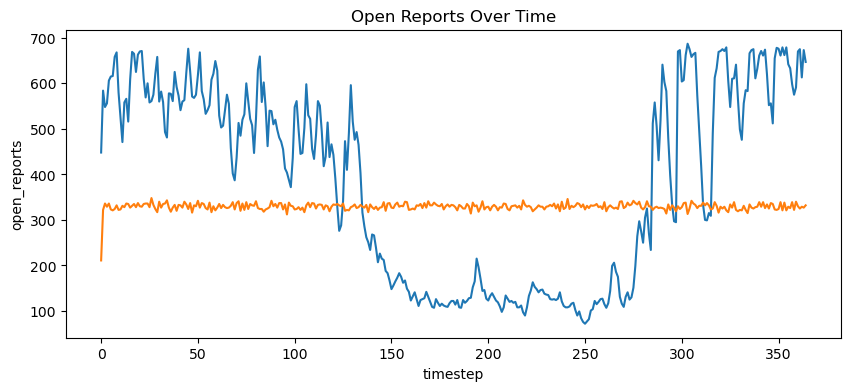

In [18]:
# plot open reports over time
plt.figure(figsize=(10,4))
sns.lineplot(data=hist_df, x='timestep', y='open_reports')
sns.lineplot(data=hist_df, x='timestep', y='inspections')
plt.title('Open Reports Over Time')
plt.show()

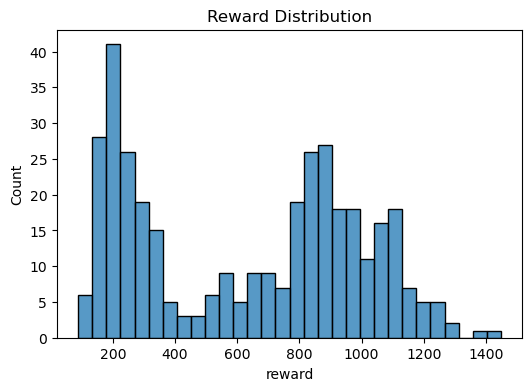

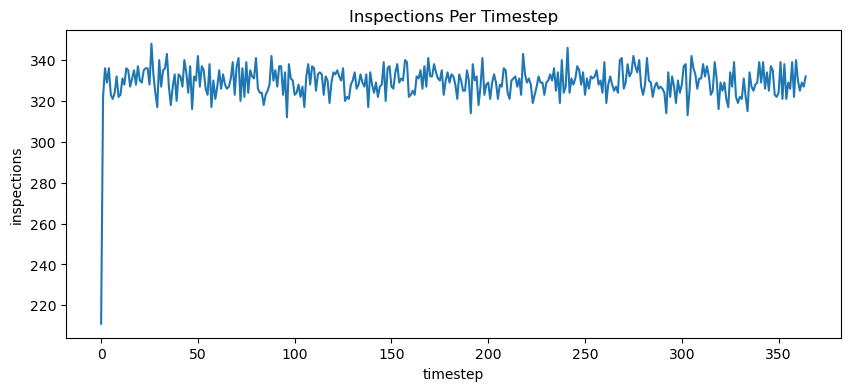

In [19]:
# histogram of rewards
plt.figure(figsize=(6,4))
sns.histplot(hist_df['reward'], bins=30)
plt.title('Reward Distribution')
plt.show()

# inspections per step
plt.figure(figsize=(10,4))
sns.lineplot(data=hist_df, x='timestep', y='inspections')
plt.title('Inspections Per Timestep')
plt.show()

### Resolution Trends and Days Open

In [ ]:
# helper to convert history list into resolution-level dataframe
def extract_resolution_info(hist):
    rows = []
    for entry in hist:
        for det in entry.get('inspection_details', []):
            rows.append({
                'timestep': entry['timestep'],
                'resolution': det.get('outcome'),
                'days_outstanding': det.get('days_outstanding_before'),
            })
    return pd.DataFrame(rows)

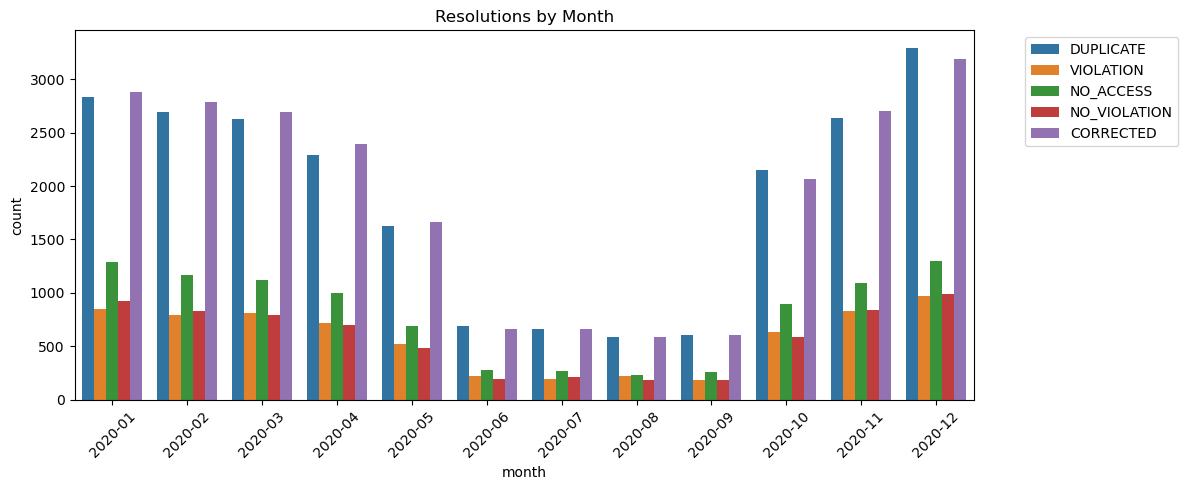

In [23]:
# compute resolution-level DataFrame from history
res_df = extract_resolution_info(history)

# convert timestep to date using history entries
if len(history) > 0:
    date_map = {entry['timestep']: pd.to_datetime(entry['date']) for entry in history}
    res_df['date'] = res_df['timestep'].map(date_map)
    res_df['month'] = res_df['date'].dt.to_period('M')
else:
    res_df['date'] = pd.NaT
    res_df['month'] = None

# plot stacked counts by month
plt.figure(figsize=(12,5))
sns.countplot(data=res_df, x='month', hue='resolution')
plt.title('Resolutions by Month')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()